In [1]:
import pickle

with open("topology_dataset.pkl", "rb") as f:
    dataset = pickle.load(f)

In [2]:
print(dataset[0]['truth'])

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [3]:
import numpy as np

threshold = 0.3 

def patch_label(truth_patch, threshold=0.3):
    fraction = np.sum(truth_patch) / truth_patch.size
    return int(fraction > threshold)

In [17]:
from persim import PersistenceImager

def vectorise_diagram(pimgr, diagram):
    vectors = []
    pimg = pimgr.transform(diagram)
    vec = pimg.ravel()
    return vec

In [5]:
from skimage.util import view_as_blocks

def split_patches(patch_size, image):
    blocks = view_as_blocks(image, block_shape=(patch_size, patch_size))
    patches = blocks.reshape(-1, patch_size, patch_size)

    return patches

In [6]:
from sklearn.model_selection import train_test_split

train_imgs, test_imgs = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42
)

In [7]:
print(len(train_imgs))
print(len(test_imgs))

10
3


In [19]:
X_train = []
y_train = []


pimgr = PersistenceImager(
    pixel_size=16,
    birth_range=(400, 700),
    pers_range=(0, 300)
    )

for image in train_imgs:  
    print('new image')
    diagrams = image['diagrams']      
    truth_image = image['truth']
    truth_patches = split_patches(16, truth_image)

    for diag, t_patch in zip(diagrams, truth_patches):
        X_train.append(vectorise_diagram(pimgr, diag))
        y_train.append(patch_label(t_patch, threshold=0.3))

new image
new image
new image
new image
new image
new image
new image
new image
new image
new image


In [20]:
with open("train_data.pkl", "wb") as f:
    pickle.dump({"X": X_train, "y": y_train}, f)

In [15]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 25.6 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 26.8 MB/s  0:00:11m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


In [21]:
min_len = min(len(x) for x in X_train)

X_train_fixed = np.array([np.asarray(x)[:min_len] for x in X_train], dtype=np.float32)

In [73]:
import xgboost as xgb


clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,

)

clf.fit(X_train_fixed, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [24]:
print(len(test_imgs))

3


In [52]:
X_test = []
y_test = []

image = test_imgs[0]
print('new image')
diagrams = image['diagrams']      
truth_image = image['truth']
truth_patches = split_patches(16, truth_image)

for diag, t_patch in zip(diagrams, truth_patches):
    X_test.append(vectorise_diagram(pimgr, diag))
    y_test.append(patch_label(t_patch, threshold=0.3))

X_test_fixed = np.array([np.asarray(x)[:min_len] for x in X_test], dtype=np.float32)

new image


In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

y_prob = clf.predict_proba(X_test_fixed)[:, 1]
y_pred = (y_prob > 0.4).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.95843505859375
Precision: 0.3627296587926509
Recall   : 0.31394820536119944
F1       : 0.3365806137359961

Confusion matrix:
[[62121  1214]
 [ 1510   691]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     63335
           1       0.36      0.31      0.34      2201

    accuracy                           0.96     65536
   macro avg       0.67      0.65      0.66     65536
weighted avg       0.96      0.96      0.96     65536



In [26]:
preds = clf.predict(X_test_fixed)

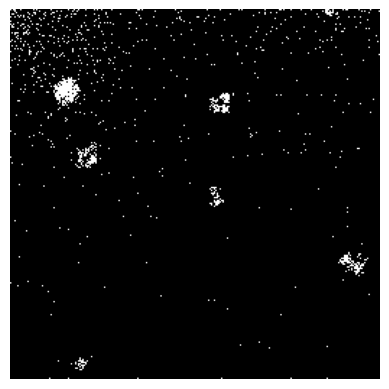

In [28]:
import numpy as np
coords = []

H, W = image['original'].shape

for i in range(0, H, 16):
    for j in range(0, W, 16):
        coords.append((i, j))


mask = np.zeros(image['original'].shape, dtype=np.uint8)

for (i, j), pred in zip(coords, preds):
    mask[i:i+16, j:j+16] = pred


import matplotlib.pyplot as plt

plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

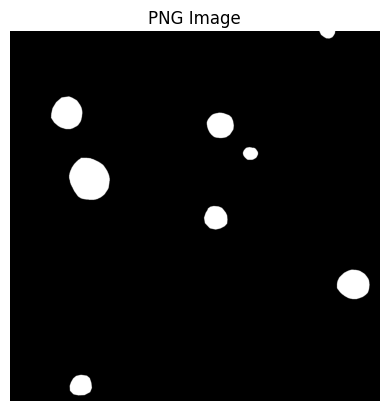

In [30]:
import matplotlib.image as mpimg


plt.imshow(image['truth'], cmap='gray')
plt.axis('off')
plt.title("PNG Image")
plt.show()

In [ ]:
def run_test(image_data):
    X_test = []
    y_test = []

    print('new image')
    diagrams = image_data['diagrams']      
    truth_image = image_data['truth']
    truth_patches = split_patches(16, truth_image)

    for diag, t_patch in zip(diagrams, truth_patches):
        X_test.append(vectorise_diagram(pimgr, diag))
        y_test.append(patch_label(t_patch, threshold=0.3))

    X_test_fixed = np.array([np.asarray(x)[:min_len] for x in X_test], dtype=np.float32)

    preds = clf.predict(X_test_fixed)

    coords = []

    H, W = image_data['original'].shape

    for i in range(0, H, 16):
        for j in range(0, W, 16):
            coords.append((i, j))


    mask = np.zeros(image_data['original'].shape, dtype=np.uint8)

    for (i, j), pred in zip(coords, preds):
        mask[i:i+16, j:j+16] = pred


    import matplotlib.pyplot as plt

    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    plt.show()

    plt.imshow(image_data['truth'], cmap='gray')
    plt.axis('off')
    plt.title("PNG Image")
    plt.show()

new image


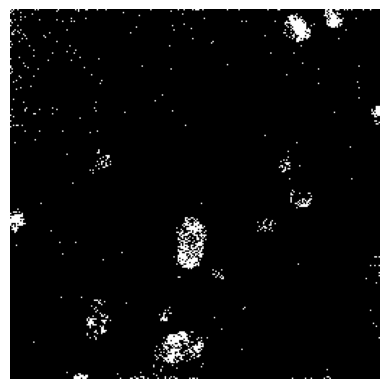

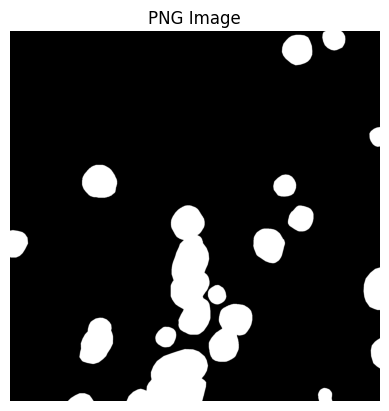

In [33]:
run_test(test_imgs[1])

new image


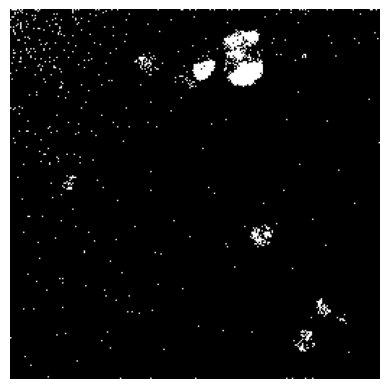

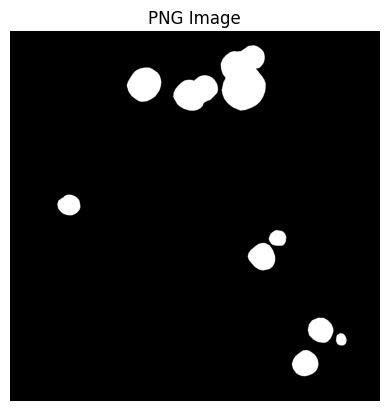

In [34]:
run_test(test_imgs[2])

In [48]:
import numpy as np

def resample_vector(x, L):
    x = np.asarray(x, dtype=np.float32)

    old_idx = np.linspace(0, 1, len(x))
    new_idx = np.linspace(0, 1, L)

    return np.interp(new_idx, old_idx, x)

In [46]:
L = 100

X_fixed = np.array([resample_vector(x, L) for x in X_train], dtype=np.float32)

In [37]:
clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

clf.fit(X_fixed, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [39]:
X_test_resampled = np.array([resample_vector(x, L) for x in X_test], dtype=np.float32)

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

y_pred = clf.predict(X_test_resampled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.965606689453125
Precision: 0.4782608695652174
Recall   : 0.26487960018173556
F1       : 0.34093567251461987

Confusion matrix:
[[62699   636]
 [ 1618   583]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     63335
           1       0.48      0.26      0.34      2201

    accuracy                           0.97     65536
   macro avg       0.73      0.63      0.66     65536
weighted avg       0.96      0.97      0.96     65536



In [40]:
def run_test(image_data):
    X_test = []
    y_test = []

    print('new image')
    diagrams = image_data['diagrams']      
    truth_image = image_data['truth']
    truth_patches = split_patches(16, truth_image)

    for diag, t_patch in zip(diagrams, truth_patches):
        X_test.append(vectorise_diagram(pimgr, diag))
        y_test.append(patch_label(t_patch, threshold=0.3))

    X_test_resampled = np.array([resample_vector(x, L) for x in X_test], dtype=np.float32)

    preds = clf.predict(X_test_resampled)

    coords = []

    H, W = image_data['original'].shape

    for i in range(0, H, 16):
        for j in range(0, W, 16):
            coords.append((i, j))


    mask = np.zeros(image_data['original'].shape, dtype=np.uint8)

    for (i, j), pred in zip(coords, preds):
        mask[i:i+16, j:j+16] = pred


    import matplotlib.pyplot as plt

    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    plt.show()

    plt.imshow(image_data['truth'], cmap='gray')
    plt.axis('off')
    plt.title("PNG Image")
    plt.show()

new image


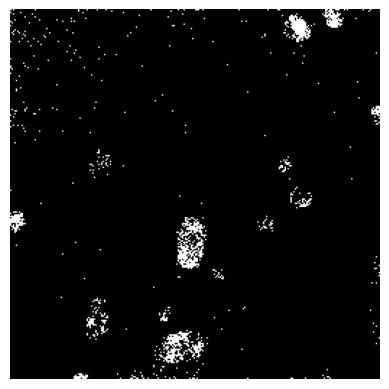

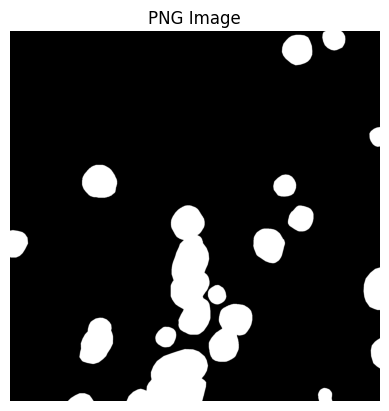

In [42]:
run_test(test_imgs[1])

In [50]:
import numpy as np
from persim import wasserstein
from sklearn.svm import SVC

# X = list of persistence diagrams (each is a Nx2 numpy array)
# y = labels (0/1)

N = len(X_fixed)
gamma = 1.0  # RBF-style scaling, can tune

# Compute pairwise Wasserstein distances
D = np.zeros((N, N))
for i in range(N):
    for j in range(i, N):
        dist = wasserstein(X[i], X[j], matching=False)  # default order-1
        D[i, j] = D[j, i] = dist

# Convert distances to similarity (RBF kernel)
K = np.exp(-gamma * D**2)

MemoryError: Unable to allocate 3.12 TiB for an array with shape (655360, 655360) and data type float64